## Домашнее задание к занятию "A/B-тесты"

### Описание задачи

![banner](https://storage.googleapis.com/kaggle-datasets-images/635/1204/126be74882028aac7241553cef0e27a7/dataset-original.jpg)

Покемоны - это маленькие существа, которые сражаются друг с другом на соревнованиях. Все покемоны имеют разные характеристики (сила атаки, защиты и т. д.) И относятся к одному или двум так называемым классам (вода, огонь и т. д.).
Профессор Оук является изобретателем Pokedex - портативного устройства, которое хранит информацию обо всех существующих покемонах. Как его ведущий специалист по данным, Вы только что получили от него запрос с просьбой осуществить аналитику данных на всех устройствах Pokedex.

### Описание набора данных
Профессор Оук скопировал все содержимое в память одного устройства Pokedex, в результате чего получился набор данных, с которым Вы будете работать в этой задаче. В этом файле каждая строка представляет характеристики одного покемона:

* `pid`: Numeric - ID покемона
* `HP`: Numeric - Очки здоровья
* `Attack`: Numeric - Сила обычной атаки
* `Defense`: Numeric - Сила обычной защиты
* `Sp. Atk`: Numeric - Сила специальной атаки
* `Sp. Def`: Numeric - Сила специальной защиты
* `Speed`: Numeric - Скорость движений
* `Legendary`: Boolean - «True», если покемон редкий
* `Class 1`: Categorical - Класс покемона
* `Class 2`: Categorical - Класс покемона

In [ ]:
import warnings
# Отключение предупреждений (warnings)
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as st
import numpy as np

from scipy.stats import f_oneway, shapiro,ttest_ind

In [ ]:
# Обратите внимание, что у покемона может быть один или два класса.
# Если у покемона два класса, считается, что они имеют одинаковую значимость.
pokemon = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/datasets_for_t-tests/main/pokemon.csv', on_bad_lines='skip')  # Откроем датасет
pokemon.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False


### Задачи

<div class="alert alert-info">
<b>Задание № 1:</b>
    
Профессор Оук подозревает, что покемоны в классе `Grass` имеют более сильную обычную атаку, чем покемоны в классе `Rock`. Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
    
Примечание: если есть покемоны, которые относятся к обоим классам, просто выбросьте их;
    
Вы можете предположить, что распределение обычных атак является нормальным для всех классов покемонов.

</div>

In [ ]:
# удалим строки , где у покемонов указано по 2 класса
df_p = pokemon[pokemon['Class 2'].isna()].copy()
df_p

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False
5,6,Charmeleon,Fire,NaN,58,64,58,80,65,80,False
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,False
10,11,Wartortle,Water,NaN,59,63,80,65,80,58,False
11,12,Blastoise,Water,NaN,79,83,100,85,105,78,False
...,...,...,...,...,...,...,...,...,...,...,...
775,776,Sliggoo,Dragon,NaN,68,75,53,83,113,60,False
776,777,Goodra,Dragon,NaN,90,100,70,110,150,80,False
788,789,Bergmite,Ice,NaN,55,69,85,32,35,28,False
789,790,Avalugg,Ice,NaN,95,117,184,44,46,28,False


<Axes: xlabel='Class 1', ylabel='Attack'>

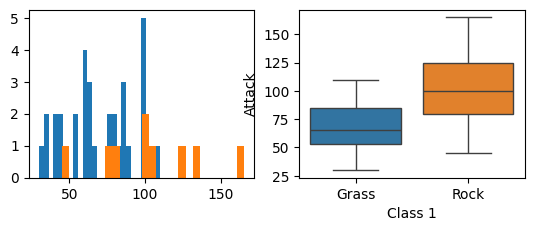

In [ ]:
sns.set_palette('tab10',desat=1)
# графически видно что атака в классах разная
D_Grass = df_p[df_p['Class 1']=='Grass']['Attack']
D_Rock = df_p[df_p['Class 1']=='Rock']['Attack']
# Посмотрим распределения обоих сравниваемых выборок на гистограмме
plt.subplot(2, 2, 1)
plt.hist(D_Grass, bins=25);
plt.hist(D_Rock, bins=25);
plt.subplot(2, 2, 2)
# и на ящике с усами
sns.boxplot(x ='Class 1',y='Attack',hue='Class 1',data=df_p[df_p['Class 1'].isin(['Grass','Rock'])])


Построим гипотезы и проверим, что средние не отличаются

* H0: сила атаки у покемонов класса Gross такая же как у покемонов класса Rock
* H1: сила атаки у покемонов класса Gross больше, чем у покемонов класса Rock

In [ ]:
stat, p = st.ttest_ind(D_Rock,D_Grass, alternative='greater' )
print(f"Статистика = {stat:.5f}, p = {p:.5f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу. Сила атаки у покемонов с классами Gross и Rock скорее всего одинаковая')
else:
    print('Отклоняем нулевую гипотезу. Сила атаки у покемонов класса Gross больше, чем у покемонов класса Rock')
print(f"Сила покемонов класса Grass = {D_Grass.mean():.5f}. Сила покемонов класса Rock = {D_Rock.mean():.5f}" )

Статистика = 3.60233, p = 0.00043
Отклоняем нулевую гипотезу. Сила атаки у покемонов класса Gross больше, чем у покемонов класса Rock
Сила покемонов класса Grass = 68.81818. Сила покемонов класса Rock = 103.33333


<div class="alert alert-info">
<b>Задание № 2:</b>
    
Профессор Оук уже долго не может спать по ночам, ведь его волнует вопрос, а правда ли, что покемоны в классе `Water` в среднем быстрее, чем покемоны в классе `Normal`.
    
    
Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
Примечание: если есть покемоны, которые относятся к обоим классам, выбросьте их;
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.
</div>

<Axes: xlabel='Class 1', ylabel='Speed'>

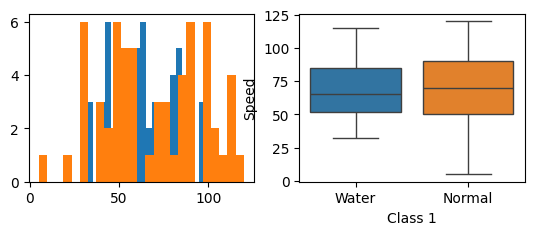

In [ ]:
# графически видно что атака в классах разная
D_Water = df_p[df_p['Class 1']=='Water']['Speed']
D_Normal = df_p[df_p['Class 1']=='Normal']['Speed']
# Посмотрим распределения обоих сравниваемых выборок на гистограмме
plt.subplot(2, 2, 1)

plt.hist(D_Water, bins=25);
plt.hist(D_Normal, bins=25);
plt.subplot(2, 2, 2)
# и на ящике с усами
sns.boxplot(x ='Class 1',y='Speed',hue='Class 1',data=df_p[df_p['Class 1'].isin(['Water','Normal'])])

Построим гипотезы и проверим, что средние не отличаются

* H0: скорость покемонов класса Water и Normal одинакова
* H1: скорость у покемонов класса Water болье, чем у покемонов класса Normal

In [ ]:
stat, p = st.ttest_ind(D_Normal, D_Water,alternative='greater'  )
print(f"Статистика = {stat:.5f}, p = {p:.5f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу. Скорость у покемонов с классами Water и Normal скорее всего одинаковая')
else:
    print('Отклоняем нулевую гипотезу. Скорость у покемонов класса Water болье, чем у покемонов класса Normal')
print(f"Скорость покемонов класса Water = {D_Water.mean():.5f}. Скорость покемонов класса Normal = {D_Normal.mean():.5f}" )

Статистика = 0.35291, p = 0.36239
Не отклоняем нулевую гипотезу. Скорость у покемонов с классами Water и Normal скорее всего одинаковая
Скорость покемонов класса Water = 67.88136. Скорость покемонов класса Normal = 69.45902


<div class="alert alert-info">
<b>Задание № 3:</b>
    
Профессор Оук тот еще безумец. Он изобрёл сыворотку, способную ускорить покемона. Однако мы усомнились в эффективности его вакцины. Професоор дал эту сыворотку следующим покемонам: смотри массив `treathed_pokemon`. Проверьте, работает ли вообще его сыворотка, убедите всех в своём выводе статистически.
    
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.

</div>

In [ ]:
# Покемоны, которые принимали сыворотку увеличения скорости
treathed_pokemon = ['Mega Beedrill', 'Mega Alakazam',
                    'Deoxys Normal Forme', 'Mega Lopunny']

Text(0.5, 1.0, 'Скорости по наличию сыворотки')

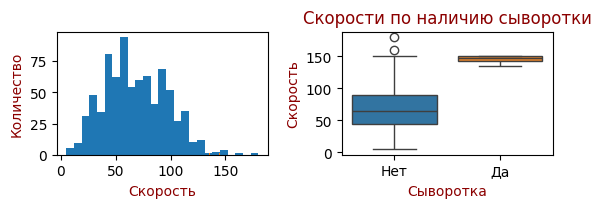

In [ ]:
# графически видно что атака в классах разная
pokemon['Serum'] = np.where(pokemon['Name'].isin(treathed_pokemon), 'Да', 'Нет')
D_Serum_Yes = pokemon[pokemon['Serum']=='Да']['Speed']
D_Serum_No = pokemon[pokemon['Serum']=='Нет']['Speed']
# Посмотрим распределения обоих сравниваемых выборок на гистограмме
plt.subplots_adjust(wspace=0.35, hspace=1)
plt.subplot(2, 2, 1)
plt.hist(D_Serum_No, bins=25);
plt.hist(D_Serum_Yes, bins=25);
plt.xlabel('Скорость',fontdict = {'color':  'darkred'})
plt.ylabel('Количество',fontdict = {'color':  'darkred'})
plt.subplot(2, 2, 2)
# и на ящике с усами
sns.boxplot(x ='Serum',y='Speed',hue='Serum',data=pokemon)
plt.xlabel('Сыворотка',fontdict = {'color':  'darkred'})
plt.ylabel('Скорость',fontdict = {'color':  'darkred'})
plt.title('Скорости по наличию сыворотки',fontdict = {'color':  'darkred'})

Построим гипотезы и проверим, что средние не отличаются

* H0: скорость покемонов, принимавших сыворотку, и не принимавших сыворотку, одинаковая
* H1: корость покемонов, принимавших сыворотку и не принимавших сыворотку, одинаковая

In [ ]:
# Очень разный объем выборок, потому применим критерий манна-уитни
print( D_Serum_Yes.shape, D_Serum_No.shape)

(4,) (796,)


In [ ]:
stat, p = st.mannwhitneyu(D_Serum_Yes,D_Serum_No )
print(f"Статистика = {stat:.5f}, p = {p:.5f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу. Скорость покемонов, принимавших сыворотку и не принимавших сыворотку, одинаковая')
else:
    print('Отклоняем нулевую гипотезу. Скорость покемонов, принимавших сыворотку и не принимавших сыворотку, разная')
print(f"Скорость покемонов, принимавших сыворотку = {D_Serum_Yes.mean():.5f}. Скорость покемонов, не принимавших сыворотку = {D_Serum_No.mean():.5f}" )

Статистика = 3164.50000, p = 0.00065
Отклоняем нулевую гипотезу. Скорость покемонов, принимавших сыворотку и не принимавших сыворотку, разная
Скорость покемонов, принимавших сыворотку = 145.00000. Скорость покемонов, не принимавших сыворотку = 67.89196


<div class="alert alert-info">
<b>Задание № 4:</b>
    
Профессор Оук всегда любил истории про легендарных покемонов. Однако профессор не очень уверен, что они лучше остальных покемонов. Оук предложил разобраться в этом нам. Проверьте, действительно ли сумма характеристик `HP`,`Attack`,`Defense` у легендарных покемонов выше, чем у других покемонов?

А произведение этих же параметров?

Найдите ответы на эти вопросы и убедите всех в своём выводе статистически.
   

Вы можете предположить, что распределение сум и произведений этих параметров является нормальным для всех классов покемонов.

</div>

Text(0.5, 1.0, 'Произведение показателей')

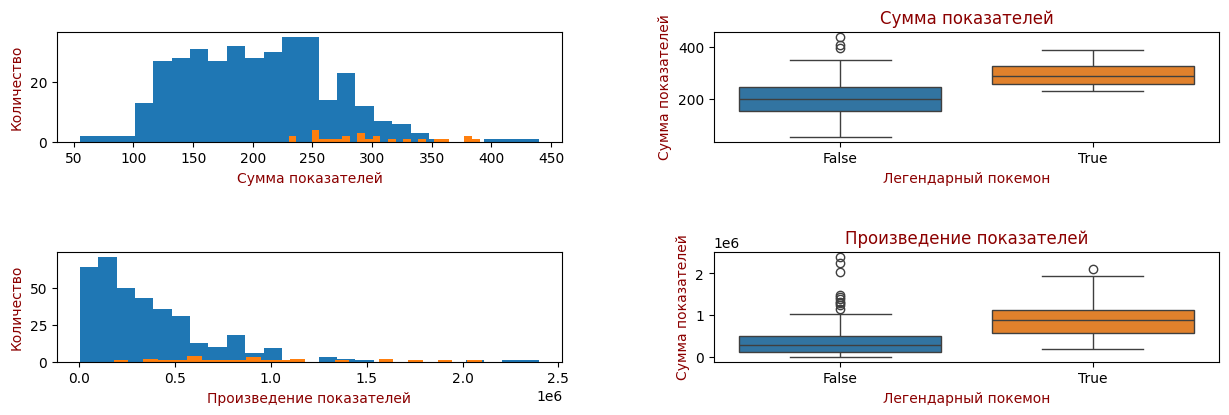

In [ ]:
df_p['Sum'] = df_p['HP']+df_p['Attack']+df_p['Defense']
df_p['Mult'] = df_p['HP']*df_p['Attack']*df_p['Defense']
D1 = df_p[df_p['Legendary']==True]['Sum']
D2 = df_p[df_p['Legendary']==False]['Sum']
# Посмотрим распределения обоих сравниваемых выборок на гистограмме
plt.figure(figsize=(15, 10))
plt.subplots_adjust(wspace=0.3, hspace=1)
plt.subplot(4, 2, 1)
plt.hist(D2, bins=25);
plt.hist(D1, bins=25);
plt.xlabel('Сумма показателей',fontdict = {'color':  'darkred'})
plt.ylabel('Количество',fontdict = {'color':  'darkred'})
plt.subplot(4, 2, 2)
# и на ящике с усами
sns.boxplot(x ='Legendary',y='Sum',hue='Legendary',data=df_p,legend=False)
plt.xlabel('Легендарный покемон',fontdict = {'color':  'darkred'})
plt.ylabel('Сумма показателей',fontdict = {'color':  'darkred'})
plt.title('Сумма показателей',fontdict = {'color':  'darkred'})


# Посмотрим распределения обоих сравниваемых выборок на гистограмме
D3 = df_p[df_p['Legendary']==True]['Mult']
D4 = df_p[df_p['Legendary']==False]['Mult']
plt.subplot(4, 2, 3)
plt.hist(D4, bins=25);
plt.hist(D3, bins=25);
plt.xlabel('Произведение показателей',fontdict = {'color':  'darkred'})
plt.ylabel('Количество',fontdict = {'color':  'darkred'})
plt.subplot(4, 2, 4)
# и на ящике с усами
sns.boxplot(x ='Legendary',y='Mult',hue='Legendary',data=df_p,legend=False)
plt.xlabel('Легендарный покемон',fontdict = {'color':  'darkred'})
plt.ylabel('Сумма показателей',fontdict = {'color':  'darkred'})
plt.title('Произведение показателей',fontdict = {'color':  'darkred'})

In [ ]:
stat, p = st.ttest_ind(D1,D2 )
print(f"Статистика = {stat:.5f}, p = {p:.5f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу. Сумма показателей HP,Attack,Defense у всех покемонов одинаковая')
else:
    print('Отклоняем нулевую гипотезу. Сумма показателей HP,Attack,Defense у легендарных и НЕ легендарных покемонов различаются')

Статистика = 7.45498, p = 0.00000
Отклоняем нулевую гипотезу. Сумма показателей HP,Attack,Defense у легендарных и НЕ легендарных покемонов различаются


In [ ]:
stat, p = st.ttest_ind(D3,D4 )
print(f"Статистика = {stat:.5f}, p = {p:.5f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу. Произведение HP,Attack,Defense показателей у всех покемонов одинаковая')
else:
    print('Отклоняем нулевую гипотезу. Произведение показателей HP,Attack,Defense у легендарных и НЕ легендарных покемонов различаются')

Статистика = 8.19409, p = 0.00000
Отклоняем нулевую гипотезу. Произведение показателей HP,Attack,Defense у легендарных и НЕ легендарных покемонов различаются


<div class="alert alert-info">
<b>Задание № 5:</b>
    
Профессор Оук частенько наблюдает за боями покемонов. После очередных таких боёв Оук выделил четыре класса `best_defence_class`, которые на его взгляд одинаковы по "силе обычной защиты" `Defense`.

Проверьте, действительно ли эти классы покемонов не отличаются по уровню защиты статистически значимо? Всё та же статистика вам в помощь!
   

Вы можете предположить, что распределение параметров защитных характеристик является нормальным для всех классов покемонов.

</div>

In [ ]:
best_defence_class = ['Rock', 'Ground', 'Steel', 'Ice']
best_defence_class

['Rock', 'Ground', 'Steel', 'Ice']

Text(0.5, 1.0, 'Сила покемонов по классам')

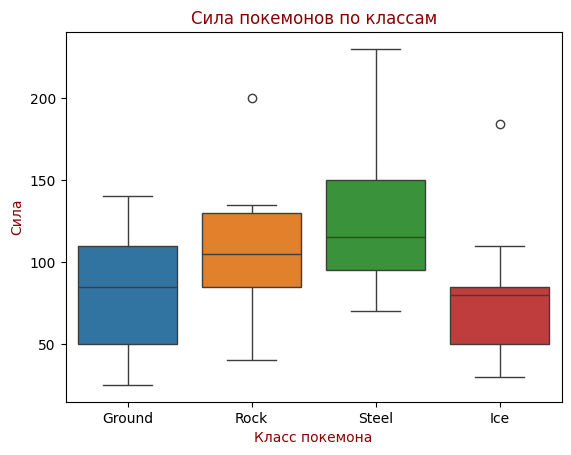

In [ ]:

sns.boxplot(x ='Class 1',y='Defense',hue='Class 1', data=df_p[df_p['Class 1'].isin(best_defence_class)])
plt.xlabel('Класс покемона',fontdict = {'color':  'darkred'})
plt.ylabel('Сила',fontdict = {'color':  'darkred'})
plt.title('Сила покемонов по классам',fontdict = {'color':  'darkred'})

Построим гипотезы и проверим, что средние не отличаются

* H0: сила атаки у покемонов с классами Ground, Rock, Steel, Ice одинакова
* H1: сила атаки покемонов минимум одного из классов Ground, Rock, Steel, Ice отличается от остальных

In [ ]:
D0 = df_p[df_p['Class 1']==best_defence_class[0]]['Defense']
D1 = df_p[df_p['Class 1']==best_defence_class[1]]['Defense']
D2 = df_p[df_p['Class 1']==best_defence_class[2]]['Defense']
D3 = df_p[df_p['Class 1']==best_defence_class[3]]['Defense']

# Проведем дисперсионный анализ выбранных групп
p, stat = f_oneway(D0,D1,D2,D3)
print(f"Статистика = {stat:.5f}, p = {p:.5f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу. Сила атаки у покемонов с классами Ground, Rock, Steel, Ice одинаковая')
else:
    print('Отклоняем нулевую гипотезу. Сила атаки покемонов минимум одного из классов Ground, Rock, Steel, Ice отличается от остальных')

Не отклоняем нулевую гипотезу. Сила атаки у покемонов с классами Ground, Rock, Steel, Ice одинаков


# **Примечание:**

Домашнее задание сдается ссылкой [Google Colab](https://colab.research.google.com/). Мы не сможем проверить его или помочь, если вы пришлете:

*   файлы;
*   архивы;
*   скриншоты кода.

Все обсуждения и консультации по выполнению домашнего задания ведутся только на соответствующем канале в Discord.

**Как правильно задавать вопросы аспирантам, преподавателям и коллегам:**

Прежде чем задать вопрос, попробуйте найти ответ в интернете. Навык самостоятельного поиска информации — один из важнейших. Каждый практикующий специалист любого уровня делает это ежедневно.

Сформулируйте вопрос по алгоритму:

1.   Что я делаю?
2.   Какого результата я ожидаю?
3.   Как фактический результат отличается от ожидаемого?
4.   Что я уже попробовал сделать, чтобы исправить проблему?

По возможности прикрепите к вопросу скриншоты либо ссылки на код. Не выкладывайте все решение, оставляйте только проблемный и воспроизводимый участок кода.